# Reproduction and variation: ISTA vs FISTA 

Reproduces the cameraman experiment *A fast iterative shrinkage-thresholding algorithm for linear inverse problems*, plus one variation. All computation is in `replication.py`; image handling and the transforms come from `image_processing.py`. Choices the paper leaves open are collected in `replication.ASSUMPTIONS`.

Section 5.1 model: `b = A x + w`, `A = R W`, with `R` a 9x9 Gaussian blur of standard deviation 4 under reflexive (Neumann) boundary conditions, `W` the inverse of a three-stage Haar transform, `w` zero-mean white Gaussian of standard deviation `1e-3`. Solve

    min_x  ||A x - b||^2 + lam ||x||_1

by ISTA and FISTA at the constant step `1/L`.

# Data

Pixels are scaled to `[0, 1]` (section 5.1). Image: the 256x256 cameraman.

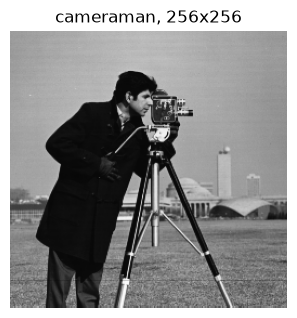

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import replication as rep

processor, image = rep.load_cameraman()
n = image.shape[0]

fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.imshow(image, cmap="gray", vmin=0, vmax=1); ax.set_title(f"cameraman, {n}x{n}"); ax.axis("off")
plt.show()

# The observation `b = A x + w`

Zero-mean white Gaussian noise of standard deviation `1e-3` added to the blurred image (section 5.1), via `ImageProcessor.add_noise` called with the paper's `1e-3`. The paper gives the standard deviation but not the realisation; the seed is ours.

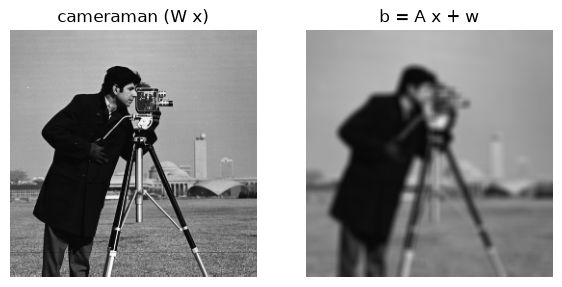

In [2]:
b = rep.observe(image, processor)
x0 = rep.initial_point(b, n, processor)   # "the initial image was the blurred image"

fig, ax = plt.subplots(1, 2, figsize=(7, 3.6))
ax[0].imshow(image, cmap="gray", vmin=0, vmax=1); ax[0].set_title("cameraman (W x)")
ax[1].imshow(b.reshape(n, n, order="F"), cmap="gray", vmin=0, vmax=1); ax[1].set_title("b = A x + w")
for a in ax: a.axis("off")
plt.show()

# problem and the step size

`F(x) = ||A x - b||^2 + lam ||x||_1` is problem (1.3), with `lam = 2e-5` (section 5.1). The smooth part gives `grad f(x) = 2 A^T (A x - b)`; Example 2.2 gives its Lipschitz constant `L(f) = 2 lambda_max(A^T A)`, computable here from the eigenvalues of `A^T A` (section 5.1). The experiments use a constant stepsize rule (section 5), so the step is `1/L`.

## Verification: the gradient and the step

In [3]:
lam = rep.LAMBDA_CAMERAMAN             # 2e-5 for the cameraman (section 5.1)
L = rep.lipschitz(n, processor)

eps = 1e-6

print(f"lambda_max(A^T A) = {L / 2:.12f},  L(f) = {L:.12f},  step 1/L = {1 / L:.12f}")
print(f"shrinkage level lam/L = {lam / L:.2e}")
print(f"F(x0) = {rep.F(x0, b, lam, processor):.4f}, of which the smooth part is "
      f"{rep.f(x0, b, processor):.4f}")

problem = rep.Problem(processor, b, x0, lam, L)

lambda_max(A^T A) = 1.000000000000,  L(f) = 2.000000000000,  step 1/L = 0.500000000000
shrinkage level lam/L = 1.00e-05
F(x0) = 24.0169, of which the smooth part is 23.9237


# Algorithms

`p_L(y) = T_{lam/L}(y - grad f(y)/L)` (equations 2.5-2.6), with the shrinkage `T_alpha` of (1.5). ISTA: `x_k = p_L(x_{k-1})` (3.1). FISTA applies the same step at an extrapolated point, the momentum of (4.2-4.3) feeding (4.1), one extra vector operation per iteration.

In [4]:
# check: ISTA's objective must be nonincreasing (Remark 3.1) and FISTA must be ahead of it
ist_check = rep.ista(x0, b, lam, 20, L, processor)
fis_check = rep.fista(x0, b, lam, 20, L, processor)
print(f"ISTA  F_0 = {ist_check.Fs[0]:.4f} -> F_20 = {ist_check.Fs[20]:.4f}, "
      f"nonincreasing: {bool(np.all(np.diff(ist_check.Fs) <= 0))}, {ist_check.seconds:.2f} s")
print(f"FISTA F_0 = {fis_check.Fs[0]:.4f} -> F_20 = {fis_check.Fs[20]:.4f}, "
      f"FISTA < ISTA at every k >= 2: {bool(np.all(fis_check.Fs[2:] < ist_check.Fs[2:]))}")

ISTA  F_0 = 24.0169 -> F_20 = 1.5462, nonincreasing: True, 8.35 s
FISTA F_0 = 24.0169 -> F_20 = 0.5759, FISTA < ISTA at every k >= 2: True


# Reproduction: the cameraman experiment (section 5.1)

Both methods run 1000 iterations at `lam = 2e-5`, the paper's settings. `replication.PUBLISHED` holds the values checked against: objectives at 100 and 200 from the caption of Figure 2, at 1000 from the text of section 5.1. The paper's third method, MTWIST, is out of scope and nothing of it is compared.

In [5]:
ist, fis = rep.reproduction(problem)

print(f"{'':6s}{'k':>6s}{'ours':>13s}{'paper':>13s}")
for method, result in (("ISTA", ist), ("FISTA", fis)):
    for k in (100, 200, 1000):
        print(f"{method:6s}{k:6d}{result.Fs[k]:13.3e}{rep.PUBLISHED[(method, k)]:13.3e}")

print(f"\nthe paper's claim, ISTA at 1000 worse than FISTA at 100: {bool(ist.Fs[1000] > fis.Fs[100])}")
print(f"\ntimes: ISTA {ist.seconds:.1f} s, FISTA {fis.seconds:.1f} s for {ist.iters} iterations")

           k         ours        paper
ISTA     100    4.764e-01    5.440e-01
ISTA     200    2.921e-01    3.600e-01
ISTA    1000    1.778e-01    2.450e-01
FISTA    100    1.723e-01    2.400e-01
FISTA    200    1.611e-01    2.280e-01
FISTA   1000    1.563e-01    2.230e-01

the paper's claim, ISTA at 1000 worse than FISTA at 100: True

times: ISTA 412.0 s, FISTA 406.7 s for 1000 iterations


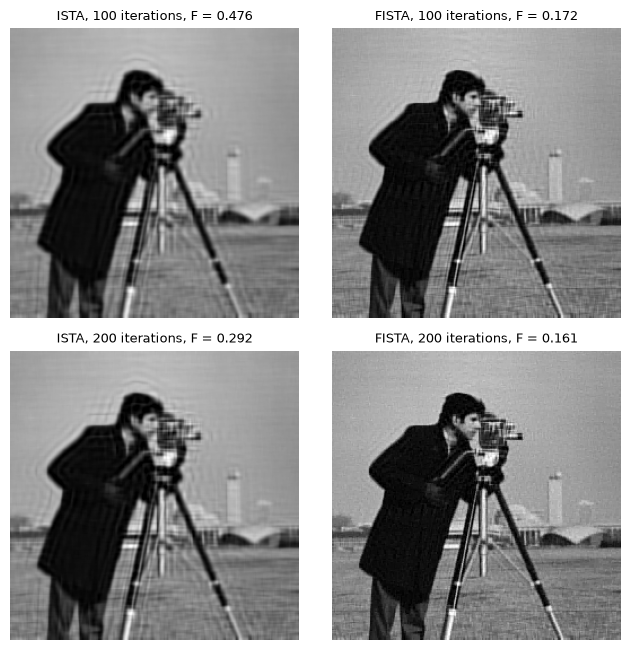

In [6]:
# the paper's Figure 2: the two methods after 100 and 200 iterations
rep.figure_reconstruction(problem)
plt.show()

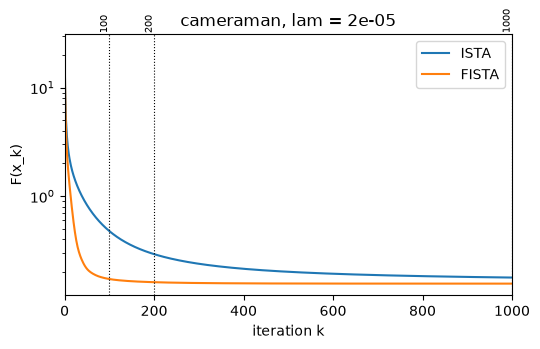

In [7]:
# the same two runs as curves
rep.figure_objective((ist, fis), lam)
plt.show()

# Variation: larger step size

Algorithms take `L` as input and step by `1/L`; the experiments use a constant step, here `t = 1/L(f) = 0.5`. Section 2.1 also gives the classical gradient condition `t_k` in `(0, 1/lambda_max(A^T A))`, i.e. `t < 2/L(f) = 1.0`. The variation runs both methods at five multiples of the paper's step and reads the answer off the curves: a curve that descends converged, one that rises did not, so `c = 1` is the paper's step and `c = 2` the classical bound. The multiples, their range and the 100-iteration budget are ours; the paper varies nothing and never reports where either method stops converging.

In [8]:
var = rep.variation(problem)
print(f"the paper's step 1/L(f) = {var.t_paper:.4f}, the classical bound 2/L(f) = {var.t_classical:.4f}")
print(f"{'':6s}{'c':>5s}{'t':>9s}{'iters':>7s}{'F_end':>12s}{'F_end/F_0':>11s}")
for method in ("ISTA", "FISTA"):
    for c in var.factors:
        Fs = var.curves[(method, c)]
        finite = Fs[np.isfinite(Fs)]
        print(f"{method:6s}{c:5g}{c * var.t_paper:9.4f}{len(finite) - 1:7d}"
              f"{finite[-1]:12.3e}{finite[-1] / Fs[0]:11.3g}")

the paper's step 1/L(f) = 0.5000, the classical bound 2/L(f) = 1.0000
          c        t  iters       F_end  F_end/F_0
ISTA    0.5   0.2500    100   8.301e-01     0.0346
ISTA   0.75   0.3750    100   6.013e-01      0.025
ISTA      1   0.5000    100   4.764e-01     0.0198
ISTA    1.5   0.7500    100   3.508e-01     0.0146
ISTA    2.5   1.2500    100   2.554e+32   1.06e+31
FISTA   0.5   0.2500    100   1.874e-01     0.0078
FISTA  0.75   0.3750    100   1.773e-01    0.00738
FISTA     1   0.5000    100   1.723e-01    0.00717
FISTA   1.5   0.7500    100   3.558e+18   1.48e+17
FISTA   2.5   1.2500    100   1.996e+99   8.31e+97


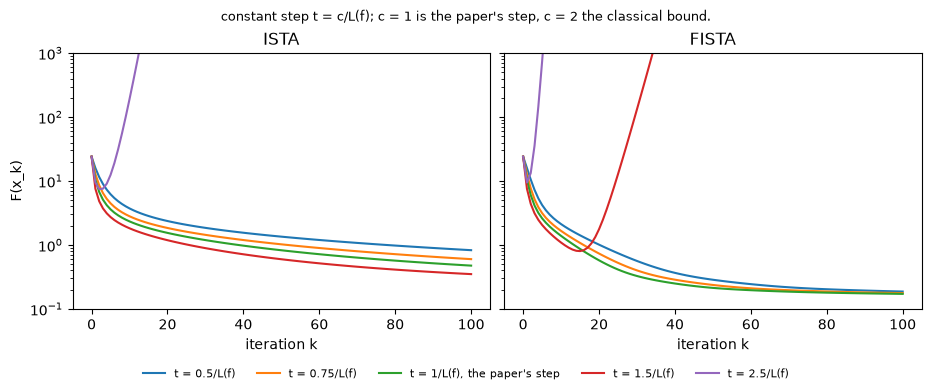

In [9]:
rep.figure_variation(var)
plt.show()

## What the variation shows

1. Below the paper's step both methods descend, and FISTA is ahead of ISTA at every multiple up to and including the paper's own step.
2. At `c = 1.5` they part: ISTA still descends (F_100 = 3.5e-1), while FISTA's objective has grown to 3.6e18 by the same iteration. The classical bound at `c = 2` sits between the `1.5` and `2.5` curves, and only the latter blows both methods up.
3. The paper's step is safe but not necessary, and FISTA is the fragile one, its momentum leaves it far less step tolerance than the plain gradient step has. The verdicts are at 100-iteration horizons.

# Deliverables

`run()` call.


reproduction, cameraman 256x256
           k         ours        paper
ISTA     100    4.764e-01    5.440e-01
ISTA     200    2.921e-01    3.600e-01
ISTA    1000    1.778e-01    2.450e-01
FISTA    100    1.723e-01    2.400e-01
FISTA    200    1.611e-01    2.280e-01
FISTA   1000    1.563e-01    2.230e-01

variation, constant step t = c/L(f)  (c = 1 paper's step, c = 2 classical bound)
          c        t  iters       F_end  F_end/F_0
ISTA    0.5   0.2500    100   8.301e-01     0.0346
ISTA   0.75   0.3750    100   6.013e-01      0.025
ISTA      1   0.5000    100   4.764e-01     0.0198
ISTA    1.5   0.7500    100   3.508e-01     0.0146
ISTA    2.5   1.2500    100   2.554e+32   1.06e+31
FISTA   0.5   0.2500    100   1.874e-01     0.0078
FISTA  0.75   0.3750    100   1.773e-01    0.00738
FISTA     1   0.5000    100   1.723e-01    0.00717
FISTA   1.5   0.7500    100   3.558e+18   1.48e+17
FISTA   2.5   1.2500    100   1.996e+99   8.31e+97
iters = iterations that stayed finite; a ratio abov

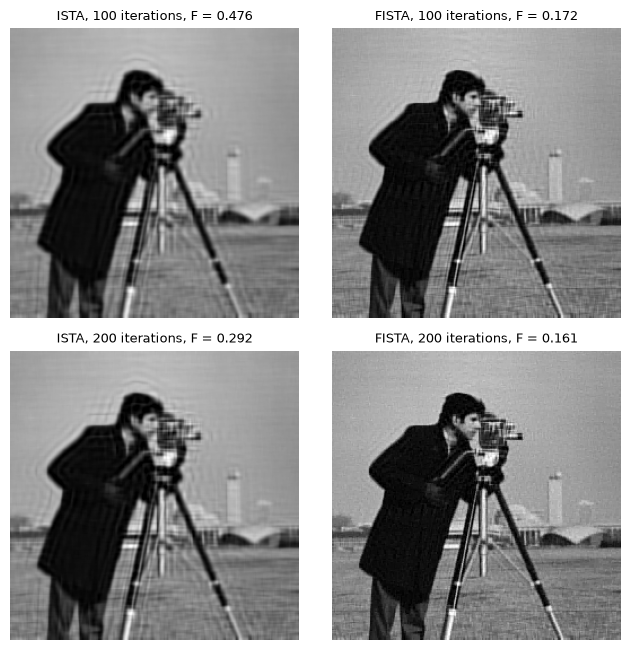

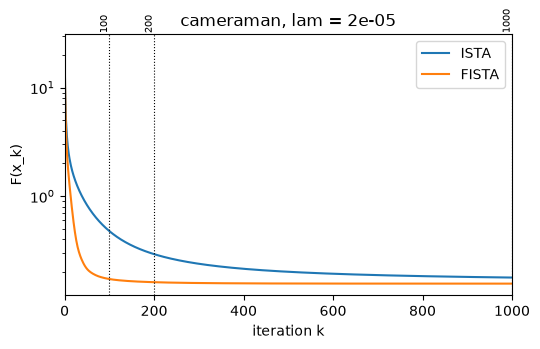

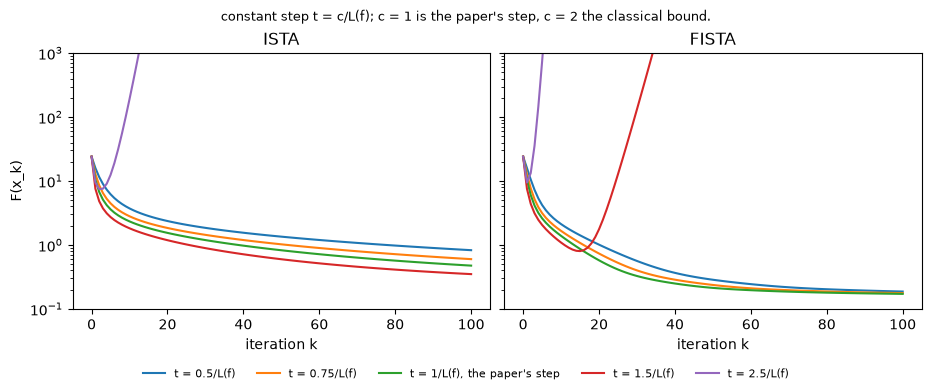

In [10]:
rep.run()
print("\nwrote:", sorted(p.name for p in rep.FIGURES_DIR.glob("*.png")))

# Comparison with the paper

Checked against every cameraman number the paper publishes: `F_100`, `F_200` (caption of Figure 2) and `F_1000` (section 5.1 text). 

In [11]:
# ours beside the paper's, at the three iterations it publishes
print(f"{'method':6s}{'k':>6s}{'ours':>13s}{'paper':>13s}{'ours/paper':>12s}")
for method, result in (("ISTA", ist), ("FISTA", fis)):
    for k in (100, 200, 1000):
        paper = rep.PUBLISHED[(method, k)]
        print(
            f"{method:6s}{k:6d}{result.Fs[k]:13.3e}{paper:13.3e}"
            f"{result.Fs[k] / paper:12.2f}"
        )

method     k         ours        paper  ours/paper
ISTA     100    4.764e-01    5.440e-01        0.88
ISTA     200    2.921e-01    3.600e-01        0.81
ISTA    1000    1.778e-01    2.450e-01        0.73
FISTA    100    1.723e-01    2.400e-01        0.72
FISTA    200    1.611e-01    2.280e-01        0.71
FISTA   1000    1.563e-01    2.230e-01        0.70
